# **Aprendizaje Basado en Problemas (ABP)**

Codigo principal organizado por:

* Sherman Abarca
* Valeria Agila
* Domenica Narvaez
* Gabriel Suarez
* Diyer Torres
* José Valencia

1. **Configuración:** Preparar el entorno en Google Colab o Jupyter Notebook importando las librerías numpy, scipy.stats, matplotlib y seaborn.



In [20]:
# ============================================================
# PRÁCTICA: Variables Aleatorias - PMF, PDF y CDF
# Probabilidad y Estadística — UNL
# ============================================================

# --- Librerías principales ---
import numpy as np                    # Operaciones numéricas y arrays
import matplotlib.pyplot as plt        # Visualizaciones base
import seaborn as sns                   # Visualizaciones estadísticas
from scipy import stats                 # Distribuciones y pruebas estadísticas
import itertools                         # Generación de espacios muestrales

# --- Configuración visual ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"]    = 100

# --- Semilla para reproducibilidad ---
np.random.seed(42)

print("✓ Librerías cargadas correctamente")
print(f"  numpy      {np.__version__}")
print(f"  matplotlib {plt.matplotlib.__version__}")
print(f"  seaborn    {sns.__version__}")

✓ Librerías cargadas correctamente
  numpy      2.0.2
  matplotlib 3.10.0
  seaborn    0.13.2


2. **Variable Aleatoria Discreta** - Lanzamiento de dado

* Defina una variable aleatoria y su PMF

In [21]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6
# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])
# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))


Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


* Visualizar la PMF

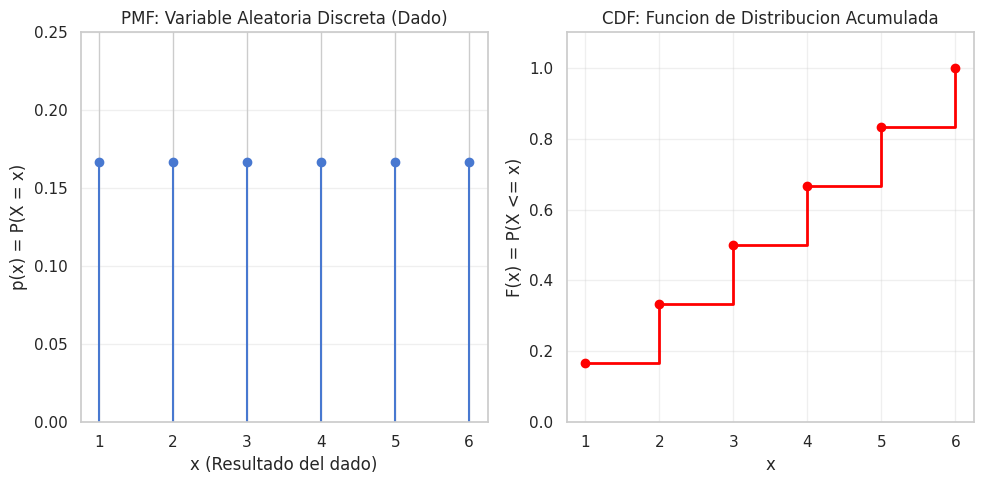

In [22]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)
# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


* Calcule posibilidades especificas

In [23]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")
# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")
# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")

P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


3. **Variable Aleatoria Continua** - Distribucion Normal
Caso: X = tiempo de respuesta de un servidor (ms), distribuido normalmente
con mu = 200 y sigma = 30.
*  Defina la distribucion y visualice la PDF:

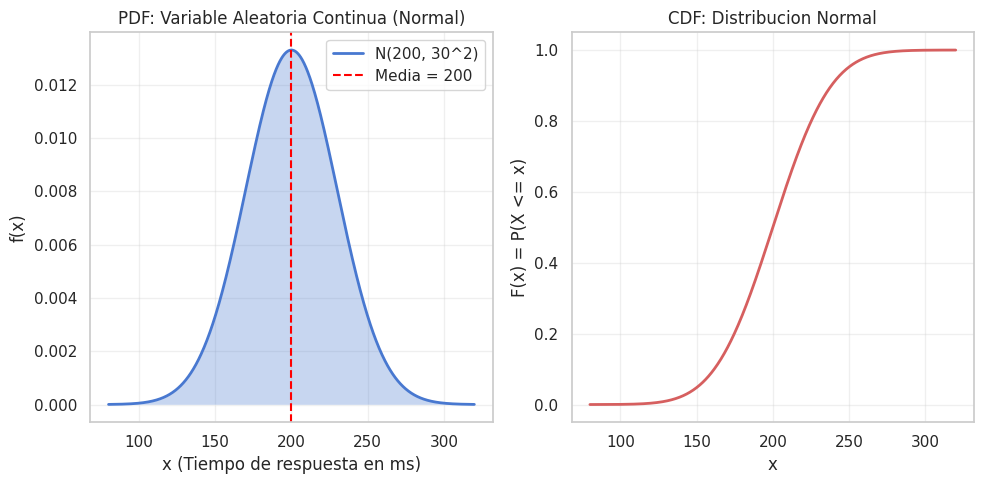

In [24]:
# Parametros de la distribucion normal
mu = 200 # media
sigma = 30 # desviacion estandar
# Crear la distribucion
dist_normal = stats.norm(loc=mu, scale=sigma)
# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
# PDF
pdf_normal = dist_normal.pdf(x)
# Visualizacion
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)
# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* Calcule posibilidades

In [25]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")
# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")
# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")
# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")

P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


**4 Comparacion Visual PMF vs PDF**

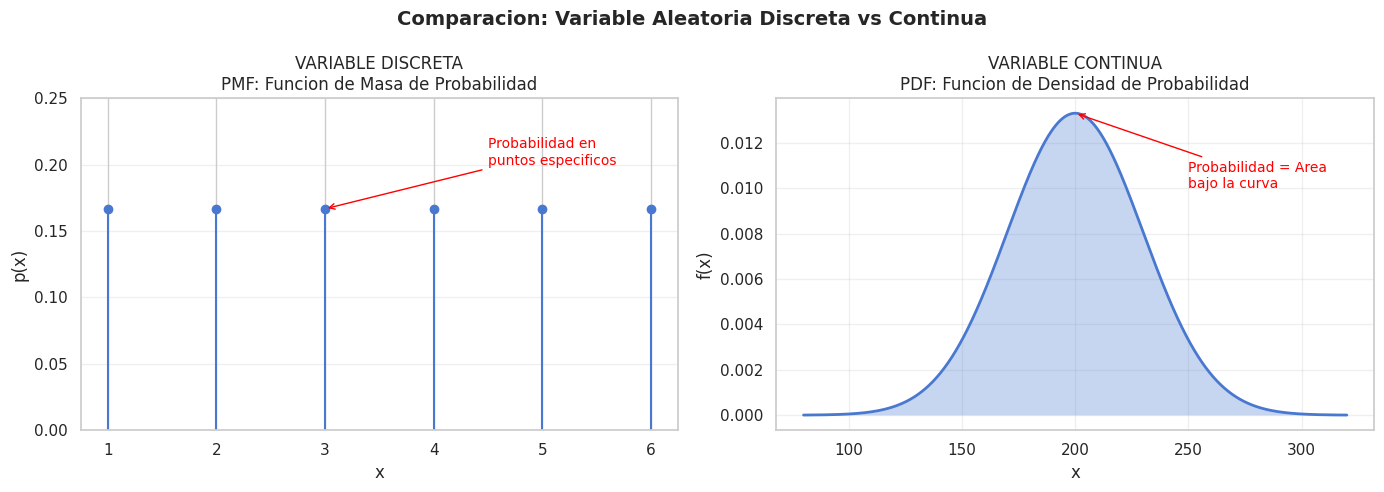

In [26]:
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)
# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6),
xytext=(4.5, 0.2),
arrowprops=dict(arrowstyle='->', color='red'),
fontsize=10, color='red')
# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)
# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, stats.norm.pdf(200,
200, 30)), xytext=(250, 0.01),
arrowprops=dict(arrowstyle='->', color='red'),
fontsize=10, color='red')
plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua',
fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

5. **Identificación en el Campus:** En grupos de 2 a 3 personas, registrar 5 variables aleatorias observadas en áreas de la UNL (Biblioteca, Cafetería, etc.), clasificándolas por tipo y distribución esperada.



In [1]:
# Plantilla para registro de variables
variables_unl = [
    {
        'nombre'              : 'Número de libros prestados por hora',
        'ubicacion'           : 'Biblioteca',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, 3, ... (enteros no negativos)',
        'distribucion_esperada': 'Poisson — conteo de eventos en intervalo fijo'
    },
    {
        'nombre'              : 'Tiempo de espera en la fila para pedir',
        'ubicacion'           : 'Cafetería',
        'tipo'                : 'Continua',
        'valores_posibles'    : '[0, +∞) minutos',
        'distribucion_esperada': 'Exponencial — tiempos entre llegadas de clientes'
    },
    {
        'nombre'              : 'Tiempo de uso de una computadora',
        'ubicacion'           : 'Laboratorios',
        'tipo'                : 'Continua',
        'valores_posibles'    : '[0, +∞) minutos',
        'distribucion_esperada': 'Normal — tiempos agrupados alrededor de una media'
    },
    {
        'nombre'              : 'Número de vehículos estacionados a las 9h00',
        'ubicacion'           : 'Estacionamiento',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, ..., capacidad máxima',
        'distribucion_esperada': 'Binomial — cada espacio ocupado o libre con prob. p'
    },
    {
        'nombre'              : 'Número de estudiantes que asisten a clase',
        'ubicacion'           : 'Aulas de clase',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, ..., N (total matriculados)',
        'distribucion_esperada': 'Binomial — cada estudiante asiste o no con prob. p'
    },
]

# Mostrar tabla formateada
import pandas as pd
df = pd.DataFrame(variables_unl)
print(df.to_string(index=False))


                                     nombre       ubicacion     tipo                       valores_posibles                               distribucion_esperada
        Número de libros prestados por hora      Biblioteca Discreta 0, 1, 2, 3, ... (enteros no negativos)       Poisson — conteo de eventos en intervalo fijo
     Tiempo de espera en la fila para pedir       Cafetería Continua                        [0, +∞) minutos    Exponencial — tiempos entre llegadas de clientes
           Tiempo de uso de una computadora    Laboratorios Continua                        [0, +∞) minutos   Normal — tiempos agrupados alrededor de una media
Número de vehículos estacionados a las 9h00 Estacionamiento Discreta         0, 1, 2, ..., capacidad máxima Binomial — cada espacio ocupado o libre con prob. p
  Número de estudiantes que asisten a clase  Aulas de clase Discreta   0, 1, 2, ..., N (total matriculados)  Binomial — cada estudiante asiste o no con prob. p


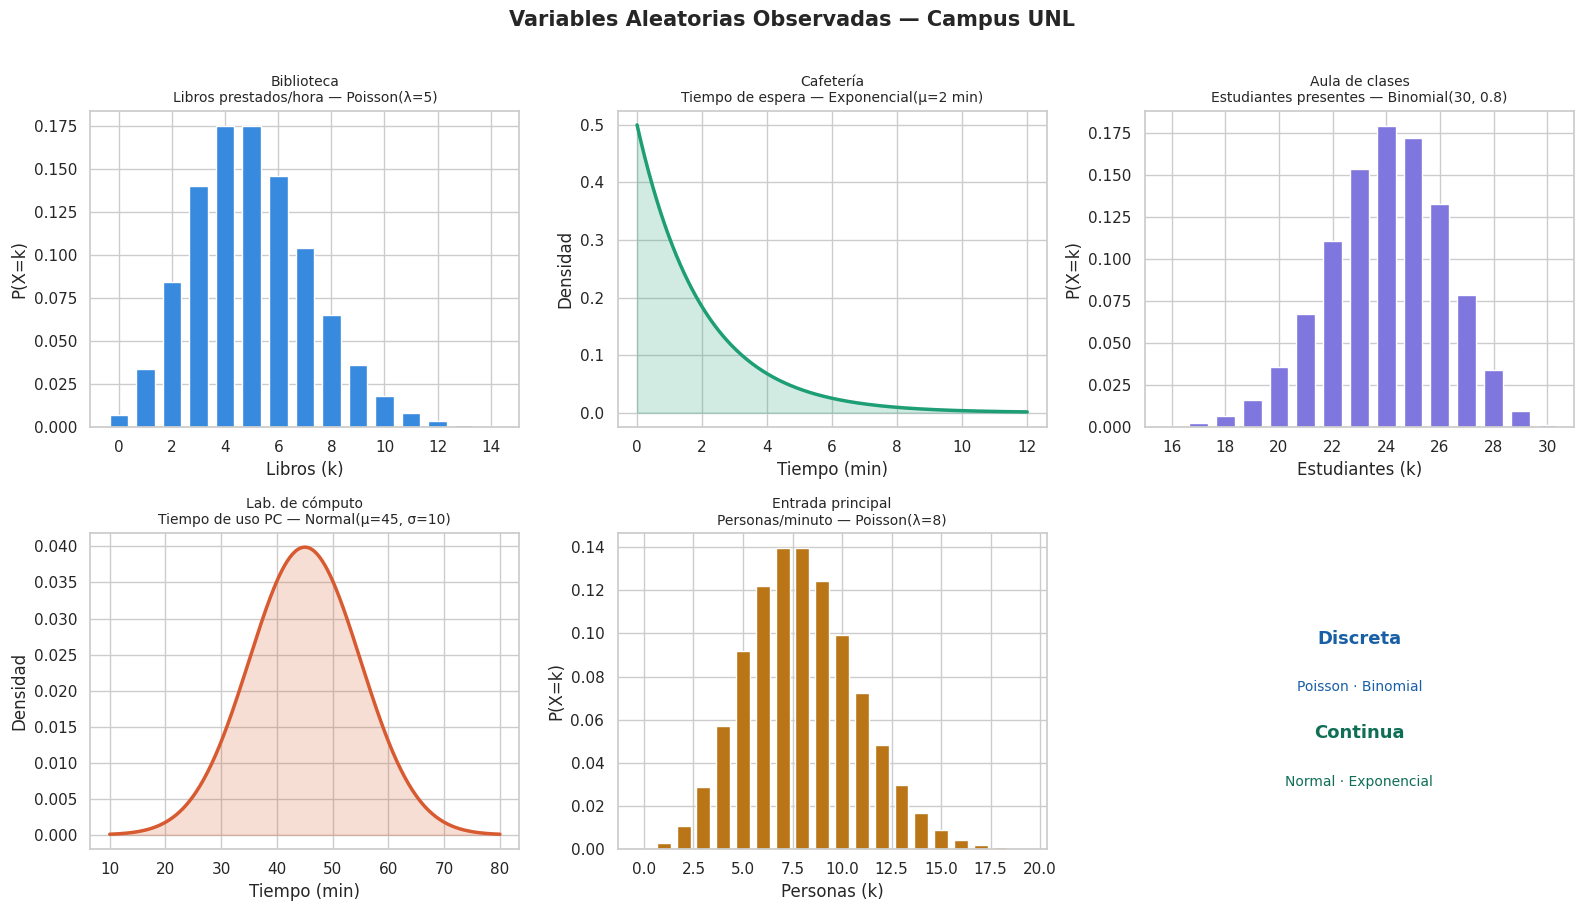

In [33]:
# ============================================================
# Gráfica de las 5 variables del campus con sus distribuciones
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. Biblioteca — Poisson (λ=5 préstamos/hora)
lam = 5
k   = np.arange(0, 15)
pmf_pois = stats.poisson.pmf(k, lam)
axes[0].bar(k, pmf_pois, color='#378ADD', edgecolor='white', width=0.7)
axes[0].set_title("Biblioteca\nLibros prestados/hora — Poisson(λ=5)", fontsize=10)
axes[0].set_xlabel("Libros (k)"); axes[0].set_ylabel("P(X=k)")

# 2. Cafetería — Exponencial (λ=0.5, media=2 min)
t    = np.linspace(0, 12, 300)
pdf_exp = stats.expon.pdf(t, scale=2)
axes[1].plot(t, pdf_exp, color='#1D9E75', linewidth=2.5)
axes[1].fill_between(t, pdf_exp, alpha=0.2, color='#1D9E75')
axes[1].set_title("Cafetería\nTiempo de espera — Exponencial(μ=2 min)", fontsize=10)
axes[1].set_xlabel("Tiempo (min)"); axes[1].set_ylabel("Densidad")

# 3. Aula — Binomial (n=30, p=0.8)
n_est, p_asist = 30, 0.80
k_bin = np.arange(0, n_est + 1)
pmf_bin = stats.binom.pmf(k_bin, n_est, p_asist)
axes[2].bar(k_bin, pmf_bin, color='#7F77DD', edgecolor='white', width=0.7)
axes[2].set_title("Aula de clases\nEstudiantes presentes — Binomial(30, 0.8)", fontsize=10)
axes[2].set_xlabel("Estudiantes (k)"); axes[2].set_ylabel("P(X=k)")
axes[2].set_xlim(15, 31)

# 4. Lab. cómputo — Normal (μ=45, σ=10 min)
x_lab = np.linspace(10, 80, 300)
pdf_lab = stats.norm.pdf(x_lab, 45, 10)
axes[3].plot(x_lab, pdf_lab, color='#D85A30', linewidth=2.5)
axes[3].fill_between(x_lab, pdf_lab, alpha=0.2, color='#D85A30')
axes[3].set_title("Lab. de cómputo\nTiempo de uso PC — Normal(μ=45, σ=10)", fontsize=10)
axes[3].set_xlabel("Tiempo (min)"); axes[3].set_ylabel("Densidad")

# 5. Entrada — Poisson (λ=8 personas/min)
lam2  = 8
k2    = np.arange(0, 20)
pmf_p2 = stats.poisson.pmf(k2, lam2)
axes[4].bar(k2, pmf_p2, color='#BA7517', edgecolor='white', width=0.7)
axes[4].set_title("Entrada principal\nPersonas/minuto — Poisson(λ=8)", fontsize=10)
axes[4].set_xlabel("Personas (k)"); axes[4].set_ylabel("P(X=k)")

# Ocultar el 6to panel vacío
axes[5].axis('off')

# Leyenda de tipos en el panel vacío
axes[5].text(0.5, 0.65, "Discreta", ha='center', fontsize=13,
             color='#185FA5', fontweight='bold', transform=axes[5].transAxes)
axes[5].text(0.5, 0.50, "Poisson · Binomial",
             ha='center', fontsize=10, color='#185FA5', transform=axes[5].transAxes)
axes[5].text(0.5, 0.35, "Continua", ha='center', fontsize=13,
             color='#0F6E56', fontweight='bold', transform=axes[5].transAxes)
axes[5].text(0.5, 0.20, "Normal · Exponencial",
             ha='center', fontsize=10, color='#0F6E56', transform=axes[5].transAxes)

plt.suptitle("Variables Aleatorias Observadas — Campus UNL",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#Trabajo Autónomo - Sherman Abarca

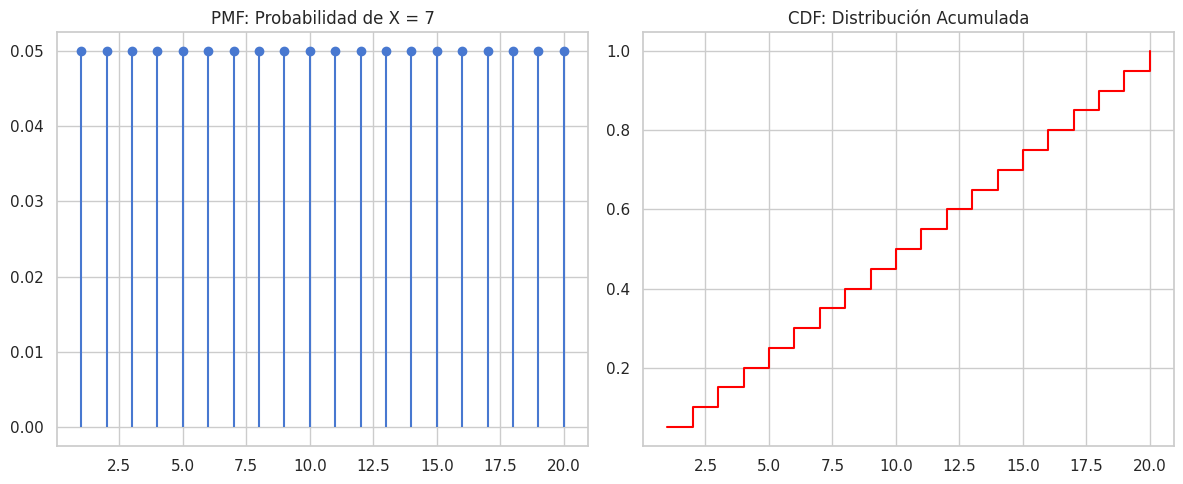

RESULTADO: P(X = 7) = 0.0500
JUSTIFICACIÓN: En una distribución uniforme de 20 valores, cada número tiene exactamente 1/20 de probabilidad.


In [38]:
# Distribución Uniforme Discreta
# Ejercicio 1

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint

# --- 1. CONFIGURACIÓN ---
low, high = 1, 21
dist_uniforme = randint(low, high)
x = np.arange(low, high)
valor_exacto = 7

# --- 2. CÁLCULOS ---
pmf_vals = dist_uniforme.pmf(x)
cdf_vals = dist_uniforme.cdf(x)
p_k = dist_uniforme.pmf(valor_exacto)

# --- 3. VISUALIZACIÓN ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.stem(x, pmf_vals, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.title(f'PMF: Probabilidad de X = {valor_exacto}')
plt.subplot(1, 2, 2)
plt.step(x, cdf_vals, where='post', color='red')
plt.title('CDF: Distribución Acumulada')
plt.tight_layout()
plt.show()

# --- 4. INTERPRETACIÓN ---
print(f"RESULTADO: P(X = {valor_exacto}) = {p_k:.4f}")
print(f"JUSTIFICACIÓN: En una distribución uniforme de 20 valores, cada número tiene exactamente 1/20 de probabilidad.")

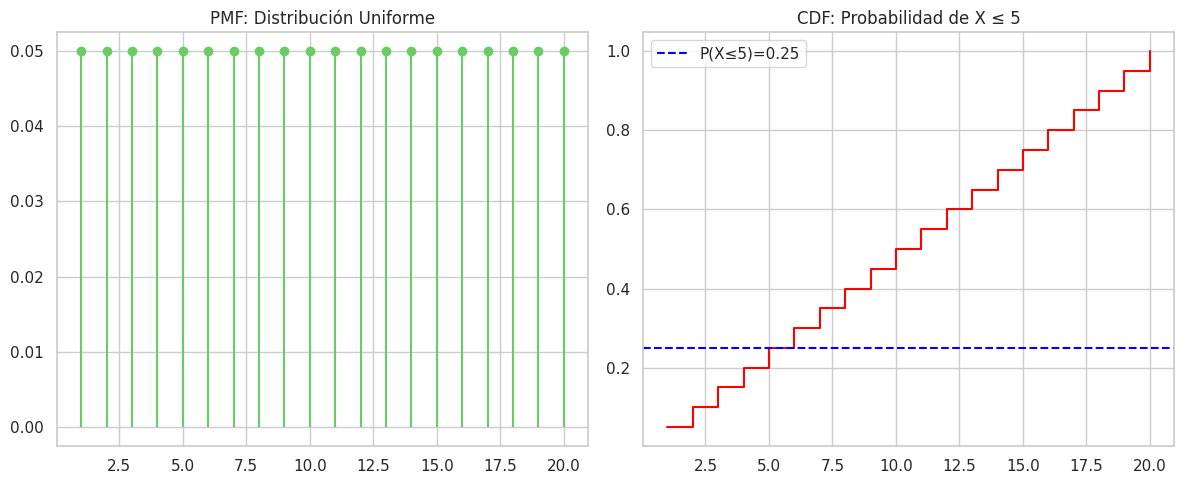

RESULTADO: P(X ≤ 5) = 0.2500
JUSTIFICACIÓN: Representa la suma de probabilidades de los valores 1 al 5. Es el 25% del total del rango.


In [39]:
# Distribución Uniforme Discreta
# Ejercicio 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint

# --- 1. CONFIGURACIÓN ---
low, high = 1, 21
dist_uniforme = randint(low, high)
x = np.arange(low, high)
limite_inferior = 5

# --- 2. CÁLCULOS ---
pmf_vals = dist_uniforme.pmf(x)
cdf_vals = dist_uniforme.cdf(x)
p_acumulada = dist_uniforme.cdf(limite_inferior)

# --- 3. VISUALIZACIÓN ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.stem(x, pmf_vals, basefmt=" ", linefmt='g-', markerfmt='go')
plt.title('PMF: Distribución Uniforme')
plt.subplot(1, 2, 2)
plt.step(x, cdf_vals, where='post', color='red')
plt.axhline(p_acumulada, color='blue', linestyle='--', label=f'P(X≤5)={p_acumulada:.2f}')
plt.legend()
plt.title(f'CDF: Probabilidad de X ≤ {limite_inferior}')
plt.tight_layout()
plt.show()

# --- 4. INTERPRETACIÓN ---
print(f"RESULTADO: P(X ≤ {limite_inferior}) = {p_acumulada:.4f}")
print(f"JUSTIFICACIÓN: Representa la suma de probabilidades de los valores 1 al 5. Es el 25% del total del rango.")

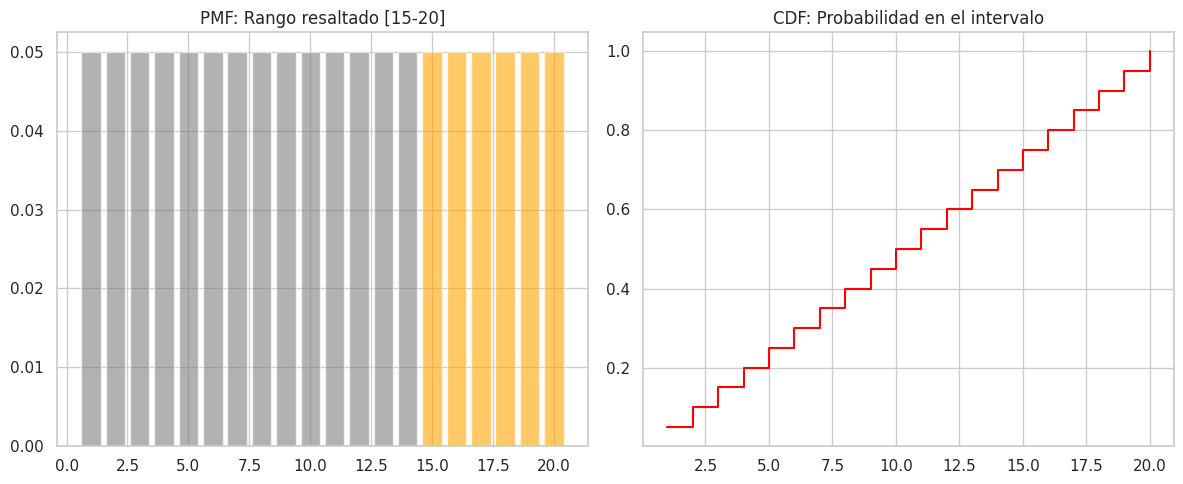

RESULTADO: P(15 ≤ X ≤ 20) = 0.3000
JUSTIFICACIÓN: Hay 6 valores posibles en este intervalo (15,16,17,18,19,20). La probabilidad es 6/20 = 0.30.


In [40]:
# Distribución Uniforme Discreta
# Ejercicio 3

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint

# --- 1. CONFIGURACIÓN ---
low, high = 1, 21
dist_uniforme = randint(low, high)
x = np.arange(low, high)
a, b = 15, 20

# --- 2. CÁLCULOS ---
pmf_vals = dist_uniforme.pmf(x)
cdf_vals = dist_uniforme.cdf(x)
# Cálculo de rango: F(b) - F(a-1)
p_rango = dist_uniforme.cdf(b) - dist_uniforme.cdf(a - 1)

# --- 3. VISUALIZACIÓN ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colores = ['orange' if a <= val <= b else 'grey' for val in x]
plt.bar(x, pmf_vals, color=colores, alpha=0.6)
plt.title(f'PMF: Rango resaltado [{a}-{b}]')
plt.subplot(1, 2, 2)
plt.step(x, cdf_vals, where='post', color='red')
plt.title(f'CDF: Probabilidad en el intervalo')
plt.tight_layout()
plt.show()

# --- 4. INTERPRETACIÓN ---
print(f"RESULTADO: P({a} ≤ X ≤ {b}) = {p_rango:.4f}")
print(f"JUSTIFICACIÓN: Hay 6 valores posibles en este intervalo (15,16,17,18,19,20). La probabilidad es 6/20 = 0.30.")

# INTERPRETACION DE RESULTADOS - DISTRIBUCION UNIFORME DISCRETA

Parámetros del Experimento
- Rango de Valores ($x$): $[1, 20]$ (Números enteros).
- Población ($N$): 20 posibles resultados.
- Probabilidad Constante ($p$): $1/20 = 0.05$ para cada evento individual.

**Resultados Clave e Interpretación**

  * Métrica
    - Probabilidad Puntual $P(X = 7)$

* Resultado
  - 0.0500

* Significado Estadístico
  - **Equiprobabilidad**: Indica que cualquier número específico tiene un 5% de probabilidad. No hay valores "favoritos" o más frecuentes.

* Métrica
  - Probabilidad Acumulada $P(X \leq 5)$

* Resultado
  - 0.2500

* Significado Estadístico
  - **Cuantil inferior**: Existe un 25% de probabilidad de que el resultado caiga en el primer cuarto del rango. Es una acumulación lineal.

* Métrica
  - Probabilidad de Rango $P(15 \leq X \leq 20)$

* Resultado
  - 0.3000

* Significado Estadístico
  - **Densidad de Intervalo**: La probabilidad de obtener un valor "alto" (los últimos 6 números) es del 30%.

**Justificación de las Gráficas**
- PMF (Función de Masa de Probabilidad):
  - Forma: Una línea de puntos (o bastones) perfectamente horizontal.
  - Justificación:
    * Al ser una distribución discreta, solo hay probabilidad en valores enteros exactos (no existe el 7.5).
    * La altura es constante ($0.05$) porque la distribución es uniforme; esto visualiza que el experimento es "justo" y no está sesgado hacia ningún número.
- CDF (Función de Distribución Acumulada):
  - Forma: Una "escalera" ascendente con una pendiente constante.
  - Justificación:
    * Cada escalón tiene la misma altura ($0.05$). Esto refleja que cada nuevo número que añadimos al conjunto aporta la misma cantidad de probabilidad.
    * A diferencia de una distribución Normal (donde la escalera es curva y se empina en el centro), aquí la escalera es una línea recta diagonal (en sus puntos de salto), lo que justifica que la probabilidad se acumula de manera uniforme en todo el dominio.

**Conclusión**
- El experimento demuestra que en la Distribución Uniforme Discreta, la incertidumbre está repartida por igual. Mientras que en una Normal la media es el punto más importante, aquí la media teórica ($10.5$) no es más probable que los extremos; simplemente es el centro aritmético del rango.

# Preguntas de control

* **¿Cual es la diferencia fundamental entre una variable aleatoria discreta y
una continua?**

La diferencia radica en la naturaleza de sus posibles resultados. Una variable discreta toma valores aislados y contables (como números enteros), mientras que una continua puede tomar cualquier valor dentro de un intervalo infinito de números reales, permitiendo decimales infinitos.

* **Por qué en una variable continua P(X = x) = 0 para cualquier valor especifico
x?**

Porque la probabilidad se define como el área bajo la curva de una función. Dado que un punto exacto en el eje horizontal no tiene ancho (su base es cero), el área resultante sobre ese punto es nula, haciendo imposible asignar probabilidad a valores únicos.

* **Explique la relacion entre la PMF/PDF y la CDF. ¿Como se obtiene una de
la otra?**

La CDF es la acumulación de la probabilidad hasta un punto. En el caso discreto, se obtiene sumando las PMF. En el continuo, se obtiene integrando la PDF. Inversamente, la PDF se halla derivando la CDF, mientras que la PMF se obtiene restando valores sucesivos de la CDF.

* **Una variable aleatoria X representa el número de estudiantes que llegan
tarde a clase. ¿Es X discreta o continua? Justifique.**

Es discreta. Los estudiantes son unidades indivisibles; puedes contar 1, 2 o 5 estudiantes, pero es físicamente imposible que lleguen "5.27" estudiantes a clase. El conjunto de resultados pertenece a los números naturales.

* **Calcule P(X = 5) para una variable continua con PDF f(x) = 2x en [0,1].
Explique su respuesta.**

El resultado es 0. Primero, el valor $x=5$ está fuera del dominio $[0, 1]$, donde la función vale cero. Segundo, al ser una variable continua, la probabilidad en cualquier punto exacto siempre es cero, independientemente de la función de densidad.

* **Dibuje aproximadamente la CDF de una variable discreta que toma valores
{1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.**

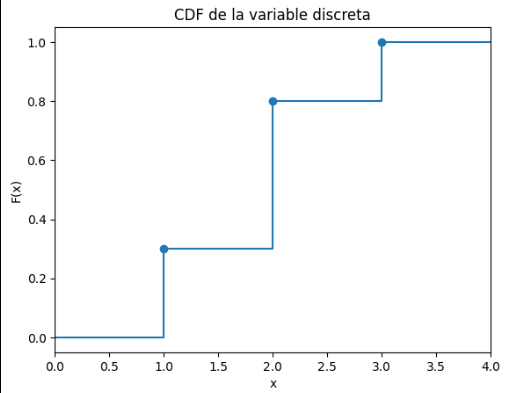

* **Identifique una variable aleatoria continua en el contexto de la carrera de
Computación y justifique porque es continua**

El tiempo de ejecución de un algoritmo. Aunque el reloj del sistema tenga un límite de precisión, el tiempo es una magnitud física continua. Un proceso puede tardar 15.4, 15.42 o 15.428 milisegundos, ocupando cualquier valor dentro de un rango medible.

